<a href="https://colab.research.google.com/github/rupankar241013006073-bit/AI_ML_lab/blob/main/AI_Lab_program1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install network matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3175 sha256=41636de64c59c6d485bb97533a4787ad2721b5d18b429f1df3f36175343473fc
  Stored in directory: /root/.cache/pip/wheels/93/07/5a/a207d6b2ad046d88823c537dd409331218b5f55aa206e820ac
Successfully built network


BFS Traversal Order starting from 'A': ['A', 'B', 'C', 'D', 'E', 'F']
DFS Traversal Order starting from 'A': ['A', 'B', 'D', 'E', 'C', 'F']


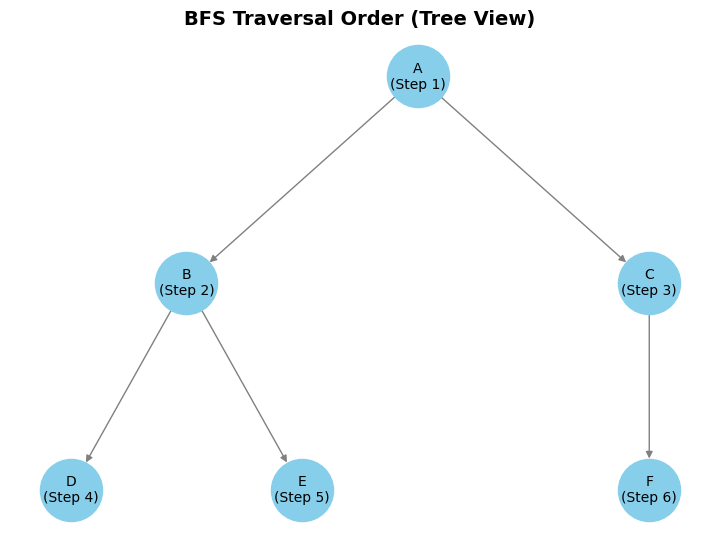

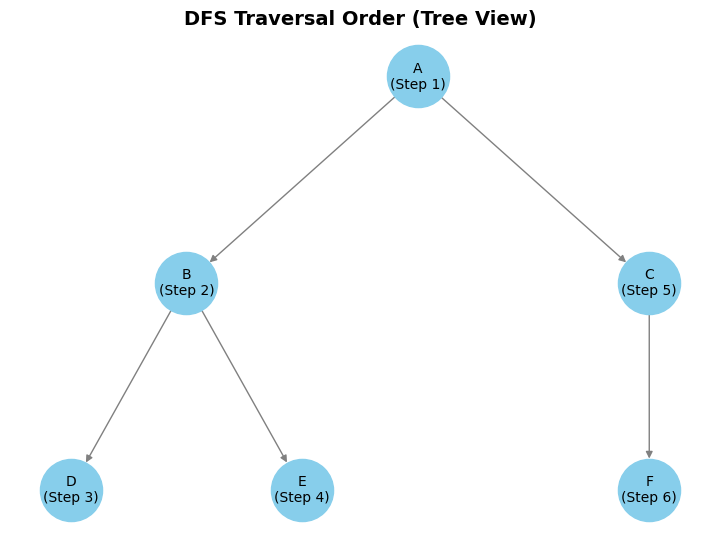

In [2]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# 1. Adjacency list representation of the graph/tree
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B'],
    'F': ['C'],
}


# 2. Breadth-First Search (BFS) Traversal
def bfs(graph, start):
    visited = set()
    order = []
    queue = deque([start])
    visited.add(start)

    while queue:
        node = queue.popleft()
        order.append(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

    return order


# 3. Depth-First Search (DFS) Traversal
def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()
    if order is None:
        order = []

    visited.add(start)
    order.append(start)

    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, order)

    return order


# 4. Execute Traversals and Print Results
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print(f"BFS Traversal Order starting from 'A': {bfs_order}")
print(f"DFS Traversal Order starting from 'A': {dfs_order}")


# 5. Draw tree diagrams annotated with visit orders
def draw_tree_with_order(graph, traversal_order, title):
    # Create a directed graph for hierarchical tree layout
    G = nx.DiGraph()
    parent_map = {'B': 'A', 'C': 'A', 'D': 'B', 'E': 'B', 'F': 'C'}

    for child, parent in parent_map.items():
        G.add_edge(parent, child)

    # Predefined positions for tree structure
    pos = {'A': (0, 2), 'B': (-1, 1), 'C': (1, 1), 'D': (-1.5, 0), 'E': (-0.5, 0), 'F': (1, 0)}

    # Create labels with node name and visit order index
    order_dict = {node: i + 1 for i, node in enumerate(traversal_order)}
    labels = {node: f"{node}\n(Step {order_dict[node]})" for node in G.nodes()}

    plt.figure(figsize=(7, 5))
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color='skyblue',
        node_size=2000,
        font_size=10,
        font_weight='bold',
        edge_color='gray',
        arrows=True,
    )
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='black')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()


# Visualize BFS and DFS visit orders
draw_tree_with_order(graph, bfs_order, 'BFS Traversal Order (Tree View)')
draw_tree_with_order(graph, dfs_order, 'DFS Traversal Order (Tree View)')